## Proyecto Final

#### Importar librerias

In [143]:
# === Librerías estándar ===
import os
import glob
import warnings
from io import StringIO
from itertools import combinations

# === Manejo de datos ===
import numpy as np
import pandas as pd

# === Visualización ===
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

# === Análisis estadístico ===
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning

# === Geoestadística y Kriging ===
from pykrige.ok import OrdinaryKriging
from pykrige.uk import UniversalKriging
from pykrige.variogram_models import (
    spherical_variogram_model,
    exponential_variogram_model,
    gaussian_variogram_model,
    linear_variogram_model,
    power_variogram_model
)
from skgstat import Variogram
from scipy.spatial.distance import pdist, squareform
from scipy.interpolate import griddata, RegularGridInterpolator

# === Geoespacial ===
import geopandas as gpd
from shapely.geometry import Point, MultiPoint
from pyproj import CRS

# === Análisis espacial (autocorrelación) ===
from libpysal.weights import DistanceBand
from esda.moran import Moran

# === Lectura y manipulación de rásters ===
import rasterio
from rasterio.mask import mask
from rasterio.features import geometry_mask
from rasterio.transform import from_origin
from rasterio.sample import sample_gen
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling as Rsp

# === Visualización cartográfica adicional ===
import contextily as ctx

# === Descarga de datos ===
import requests



#### Descarga de topografía

In [2]:

# ID del dataset en Zenodo
record_id = "15715800"

# Carpeta destino local
carpeta_destino = os.path.join(os.getcwd(), "TopoNasaDEM")
os.makedirs(carpeta_destino, exist_ok=True)

# 1. Descargar los archivos desde Zenodo
api_url = f"https://zenodo.org/api/records/{record_id}"
respuesta = requests.get(api_url)

if respuesta.status_code == 200:
    record = respuesta.json()
    
    for archivo in record.get("files", []):
        nombre_archivo = archivo["key"]
        if nombre_archivo.endswith((".tif", ".tiff")):
            url_descarga = archivo["links"]["self"]
            ruta_local = os.path.join(carpeta_destino, nombre_archivo)
            print(f"Descargando: {nombre_archivo}")
            with requests.get(url_descarga, stream=True) as r:
                with open(ruta_local, 'wb') as f:
                    f.write(r.content)
else:
    print(f"❌ Error al acceder al registro Zenodo: {respuesta.status_code}")

# 2. Verificar archivos descargados
archivos_descargados = os.listdir(carpeta_destino)
print("\nArchivos en la carpeta:")
for f in archivos_descargados:
    print("  -", f)

# 3. Buscar automáticamente el primer .tif/.tiff
tif_files = [f for f in archivos_descargados if f.endswith(('.tif', '.tiff'))]

if tif_files:
    ruta_topo = os.path.join(carpeta_destino, tif_files[0])
    print(f"\n✓ Archivo TIFF detectado: {ruta_topo}")

    # 4. Leer el archivo raster
    with rasterio.open(ruta_topo) as src:
        print("\n📄 Información del raster:")
        print("  - CRS:", src.crs)
        print("  - Dimensiones (ancho x alto):", src.width, "x", src.height)
        print("  - Resolución:", src.res)
        print("  - Número de bandas:", src.count)
        print("  - Tipo de dato:", src.dtypes[0])
else:
    print(" No se encontró ningún archivo .tif o .tiff en la carpeta.")

Descargando: nasadem_SimpBasinMagdCau.tif

Archivos en la carpeta:
  - nasadem_SimpBasinMagdCau.tif
  - nasadem_SimpBasinMagdCau.tif.aux.xml

✓ Archivo TIFF detectado: C:\Users\USUARIO\Documents\AnalisisGeoEspacial\Superficies\TopoNasaDEM\nasadem_SimpBasinMagdCau.tif

📄 Información del raster:
  - CRS: EPSG:4326
  - Dimensiones (ancho x alto): 19057 x 37279
  - Resolución: (0.00026949458523585647, 0.00026949458523585647)
  - Número de bandas: 1
  - Tipo de dato: int16


#### Descarga de Precipitacion satelital

In [3]:
# ID del dataset en Zenodo
record_id = "16255146"

# Carpeta destino local
carpeta_destino = os.path.join(os.getcwd(), "PrecipitacionImerg")
os.makedirs(carpeta_destino, exist_ok=True)

# 1. Descargar los archivos desde Zenodo
api_url = f"https://zenodo.org/api/records/{record_id}"
respuesta = requests.get(api_url)

if respuesta.status_code == 200:
    record = respuesta.json()
    
    for archivo in record.get("files", []):
        nombre_archivo = archivo["key"]
        if nombre_archivo.endswith((".tif", ".tiff")):
            url_descarga = archivo["links"]["self"]
            ruta_local = os.path.join(carpeta_destino, nombre_archivo)
            print(f"Descargando: {nombre_archivo}")
            with requests.get(url_descarga, stream=True) as r:
                with open(ruta_local, 'wb') as f:
                    f.write(r.content)
else:
    print(f"❌ Error al acceder al registro Zenodo: {respuesta.status_code}")

# 2. Verificar archivos descargados
archivos_descargados = os.listdir(carpeta_destino)
print("\nArchivos en la carpeta:")
for f in archivos_descargados:
    print("  -", f)

# 3. Buscar automáticamente el primer .tif/.tiff
tif_files = [f for f in archivos_descargados if f.endswith(('.tif', '.tiff'))]

if tif_files:
    ruta_topo = os.path.join(carpeta_destino, tif_files[0])
    print(f"\n✓ Archivo TIFF detectado: {ruta_topo}")

    # 4. Leer el archivo raster
    with rasterio.open(ruta_topo) as src:
        print("\n📄 Información del raster:")
        print("  - CRS:", src.crs)
        print("  - Dimensiones (ancho x alto):", src.width, "x", src.height)
        print("  - Resolución:", src.res)
        print("  - Número de bandas:", src.count)
        print("  - Tipo de dato:", src.dtypes[0])
else:
    print(" No se encontró ningún archivo .tif o .tiff en la carpeta.")

Descargando: precip_2022_total.tif

Archivos en la carpeta:
  - precip_2022_total.tif

✓ Archivo TIFF detectado: C:\Users\USUARIO\Documents\AnalisisGeoEspacial\Superficies\PrecipitacionImerg\precip_2022_total.tif

📄 Información del raster:
  - CRS: EPSG:4326
  - Dimensiones (ancho x alto): 58 x 113
  - Resolución: (0.08983152841195215, 0.08983152841195215)
  - Número de bandas: 1
  - Tipo de dato: float64


#### Descarga de datos Estaciones (2022)

In [4]:

ColumnasInteres = ["CodigoEstacion", "NombreEstacion", "Fecha", "Valor"]

# Crear carpeta de descarga
carpeta_descarga = os.path.join(os.getcwd(), "csv_descargados_estaciones")
os.makedirs(carpeta_descarga, exist_ok=True)

# Lista de Zenodo record IDs
record_ids = ["15514418", "15514388"]  # Puedes poner IDs distintos aquí
lista_df = []

for record_id in record_ids:
    api_url = f"https://zenodo.org/api/records/{record_id}"
    respuesta = requests.get(api_url)

    if respuesta.status_code != 200:
        print(f"Error al obtener metadata del ID {record_id}")
        continue

    data = respuesta.json()

    
    for archivo in data.get("files", []):
        nombre = archivo["key"]
        enlace = archivo["links"]["self"]

        if nombre.endswith(".csv"):
            print(f"Descargando: {nombre} desde {enlace}")
            r = requests.get(enlace)
            if r.status_code == 200:
                ruta_local = os.path.join(carpeta_descarga, nombre)
                with open(ruta_local, "wb") as f:
                    f.write(r.content)

                # Leer el CSV directamente desde el contenido de la respuesta
                df = pd.read_csv(StringIO(r.text))
                columnas_validas = [col for col in ColumnasInteres if col in df.columns]
                df_filtrado = df[columnas_validas].copy()
                lista_df.append(df_filtrado)
            else:
                print(f"Error al descargar {nombre}: {r.status_code}")

# Procesar archivos descargados
if lista_df:
    df_total = pd.concat(lista_df, ignore_index=True)
    df_total["Fecha"] = pd.to_datetime(df_total["Fecha"], errors="coerce")
    df_2022 = df_total[df_total["Fecha"].dt.year == 2022]
    grupos_2022 = dict(tuple(df_2022.groupby("CodigoEstacion")))
    print(f"Archivos descargados en: {carpeta_descarga}")
else:
    print("No se descargaron archivos válidos.")



Descargando: Santander9.csv desde https://zenodo.org/api/records/15514419/files/Santander9.csv/content
Descargando: Santander1.csv desde https://zenodo.org/api/records/15514419/files/Santander1.csv/content
Descargando: Santander8.csv desde https://zenodo.org/api/records/15514419/files/Santander8.csv/content
Descargando: VC5.csv desde https://zenodo.org/api/records/15514419/files/VC5.csv/content
Descargando: VC2.csv desde https://zenodo.org/api/records/15514419/files/VC2.csv/content
Descargando: Tolima6.csv desde https://zenodo.org/api/records/15514419/files/Tolima6.csv/content
Descargando: VC1.csv desde https://zenodo.org/api/records/15514419/files/VC1.csv/content
Descargando: Tolima1.csv desde https://zenodo.org/api/records/15514419/files/Tolima1.csv/content
Descargando: Tolima3.csv desde https://zenodo.org/api/records/15514419/files/Tolima3.csv/content
Descargando: VC4.csv desde https://zenodo.org/api/records/15514419/files/VC4.csv/content
Descargando: NS4.csv desde https://zenodo.or

In [110]:

# === Parámetros ===
ruta_coord = carpeta_descarga  # Asegúrate de definir 'carpeta_descarga'
ColumnasInteres = ["CodigoEstacion", "Fecha", "Valor"]

# === Buscar archivos CSV ===
archivos_csv = glob.glob(os.path.join(ruta_coord, "*.csv"))

# === Leer y filtrar cada archivo solo con datos del 2022 ===
lista_df = []
for f in archivos_csv:
    df = pd.read_csv(f)
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    df_2022 = df[df["Fecha"].dt.year == 2022]
    lista_df.append(df_2022)

# === Unir todos los datos filtrados ===
df_total = pd.concat(lista_df, ignore_index=True)

# === Filtrar columnas de interés ===
df_filtrado = df_total[ColumnasInteres].copy()

# === Eliminar estación 23055040 desde ya ===
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 23055040].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 51020010].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 52050140].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 52050040].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 52045020].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 52040160].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 52030060].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 52025020].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 12030010].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 16020250].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 16030030].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 53115010].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 12010170].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 52050050].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 12030020].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 12010110].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 11070030].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 12010110].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 16055010].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 16030080].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 16010020].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 16010110].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 35080050].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 35070480].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 44010100].copy()
df_filtrado = df_filtrado[df_filtrado["CodigoEstacion"] != 44015030].copy()


# === Agrupar por estación ===
grupos_2022 = dict(tuple(df_filtrado.groupby("CodigoEstacion")))

# === Estaciones con al menos 365 días de datos ===
grupos_filtrados = {codigo: df for codigo, df in grupos_2022.items() if len(df) >= 365}

# === Calcular lluvia total anual por estación ===
lluvia_total_2022 = {codigo: df["Valor"].sum() for codigo, df in grupos_filtrados.items()}

# === Crear carpeta de salida para lluvia total ===
carpeta_lluvia = os.path.join(os.getcwd(), "Lluvia_total")
os.makedirs(carpeta_lluvia, exist_ok=True)

# === Guardar lluvia total en CSV ===
df_lluvia_total = pd.DataFrame.from_dict(lluvia_total_2022, orient="index", columns=["LluviaTotal_2022"])
df_lluvia_total.index.name = "CodigoEstacion"
df_lluvia_total.reset_index(inplace=True)
df_lluvia_total.to_csv(os.path.join(carpeta_lluvia, "lluvia_total_2022_por_estacion.csv"), index=False)

# === Mostrar resultados ===
print("\n\nLluvia total 2022 por estación\n\n", df_lluvia_total.head())

print("\n\nEstaciones usadas en el análisis\n\n")
for CodigoEstacion, df in grupos_filtrados.items():
    print(f"{CodigoEstacion}: {len(df)}")




Lluvia total 2022 por estación

    CodigoEstacion  LluviaTotal_2022
0        21010140            1906.0
1        21050250            2060.0
2        21055030            2063.2
3        21100080            1625.0
4        21160050            2552.0


Estaciones usadas en el análisis


21010140: 365
21050250: 365
21055030: 365
21100080: 365
21160050: 365
21190410: 365
21200160: 365
21202160: 365
21205940: 365
21205980: 365
21206280: 365
21220040: 365
22050060: 365
23020100: 365
23050230: 365
23060370: 365
23070020: 365
23080720: 365
23100030: 365
23110040: 365
23120200: 365
23120210: 365
23125090: 365
23130010: 365
23180050: 365
23190280: 365
23195502: 365
24010070: 365
24010750: 365
24010830: 365
24015120: 365
24015260: 365
24020220: 365
24020230: 365
24025040: 365
24030800: 365
24035040: 365
24040050: 365
24060050: 365
26010030: 365
26025070: 365
26040260: 365
26050270: 365
26055120: 365
26065020: 365
26075010: 365
26075040: 365
26080070: 365
26100300: 365
26120170: 365
26125061: 36

In [111]:
# === Crear carpeta de descarga ===
carpeta_descarga2 = os.path.join(os.getcwd(), "coords_estaciones")
os.makedirs(carpeta_descarga2, exist_ok=True)

# === Descargar archivo CNE_IDEAM desde Zenodo ===
record_id = "15514435"
api_url = f"https://zenodo.org/api/records/{record_id}"
respuesta = requests.get(api_url)
record = respuesta.json()

for file in record['files']:
    if "CNE_IDEAM.csv" in file['key']:
        url_descarga = file['links']['self']
        ruta_csv = os.path.join(carpeta_descarga2, file['key'])
        with requests.get(url_descarga, stream=True) as r:
            with open(ruta_csv, 'wb') as f:
                f.write(r.content)

# === Leer archivo con coordenadas ===
df_coord = pd.read_csv(ruta_csv)
df_coord["Codigo"] = pd.to_numeric(df_coord["CODIGO"], errors="coerce")

# === Unir con lluvia total por estación ===
df_lluvia_total["CodigoEstacion"] = pd.to_numeric(df_lluvia_total["CodigoEstacion"], errors="coerce")
df_merge = df_lluvia_total.merge(df_coord, left_on="CodigoEstacion", right_on="Codigo")

# === Crear geometría con X, Y en EPSG:9377 ===
geometry = [Point(xy) for xy in zip(df_merge["X"], df_merge["Y"])]
gdf_lluvia = gpd.GeoDataFrame(df_merge[["CodigoEstacion", "LluviaTotal_2022"]], geometry=geometry, crs="EPSG:9377")

# === Reproyectar a EPSG:4326 ===
gdf_lluvia_4326 = gdf_lluvia.to_crs(epsg=4326)

# === Guardar como GeoPackage ===
salida_gpkg = os.path.join(os.getcwd(), "Lluvia_total", "lluvia_total_2022_WGS84.gpkg")
gdf_lluvia_4326.to_file(salida_gpkg, layer="lluvia_2022", driver="GPKG")

print("\n\nGeoDataFrame final en EPSG:4326:\n")
print(gdf_lluvia_4326.head())




GeoDataFrame final en EPSG:4326:

   CodigoEstacion  LluviaTotal_2022                   geometry
0        21010140            1906.0  POINT (-76.36083 1.86439)
1        21050250            2060.0    POINT (-76.09517 2.501)
2        21055030            2063.2        POINT (-76.16 2.24)
3        21100080            1625.0  POINT (-75.20669 2.61528)
4        21160050            2552.0  POINT (-74.84297 3.67172)


#### Descargar cuenca

Descargando: ParteCuencaMagd.dbf
Descargando: SubcuencasMagd.shp
Descargando: SubcuencasMagd.shx
Descargando: ParteCuencaMagd.cpg
Descargando: SubcuencasMagd.dbf
Descargando: SubcuencasMagd.prj
Descargando: ParteCuencaMagd.prj
Descargando: ParteCuencaMagd.shp
Descargando: SubcuencasMagd.cpg
Descargando: ParteCuencaMagd.shx
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Id        1 non-null      object  
 1   geometry  1 non-null      geometry
dtypes: geometry(1), object(1)
memory usage: 148.0+ bytes


<Axes: >

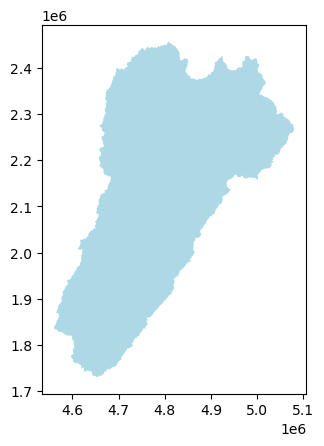

In [112]:
#Visualizar datos

record_id = "15713307"  # 
carpeta_destino = os.path.join(os.getcwd(), "Zona_descargado")
os.makedirs(carpeta_destino, exist_ok=True)

# Construir URL del API
api_url = f"https://zenodo.org/api/records/{record_id}"
respuesta = requests.get(api_url)

if respuesta.status_code == 200:
    record = respuesta.json()
    
    for archivo in record.get("files", []):
        nombre_archivo = archivo["key"]
        
        # Filtrar extensiones típicas de shapefile
        if any(nombre_archivo.endswith(ext) for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg", ".sbn", ".sbx"]):
            url_descarga = archivo["links"]["self"]
            ruta_local = os.path.join(carpeta_destino, nombre_archivo)
            print(f"Descargando: {nombre_archivo}")
            with requests.get(url_descarga, stream=True) as r:
                with open(ruta_local, 'wb') as f:
                    f.write(r.content)
else:
    print(f" Error al acceder al registro Zenodo: {respuesta.status_code}")

ruta_shp = os.path.join(carpeta_destino, "ParteCuencaMagd.shp")  
ZonaEstudio = gpd.read_file(ruta_shp)
type(ZonaEstudio)
ZonaEstudio.info()
ZonaEstudio.head(2)
ZonaEstudio.plot(color="lightblue")

In [113]:
# === Reproyectar ZonaEstudio de 9377 a 4326 ===
ZonaEstudio = ZonaEstudio.to_crs(epsg=4326)

# === Filtrar estaciones que intersectan con el polígono ===
#Estaciones_filtradas = gpd.sjoin(gdf_lluvia_4326, ZonaEstudio, how="inner", predicate="intersects")

# === Seleccionar columnas clave ===
Estaciones_filtradas = gdf_lluvia_4326[["CodigoEstacion", "LluviaTotal_2022", "geometry"]]

# === Exportar a GeoJSON ===
carpeta_salida = os.path.join(os.getcwd(), "Lluvia_total")
os.makedirs(carpeta_salida, exist_ok=True)

ruta_geojson = os.path.join(carpeta_salida, "lluvia_total_filtradas.geojson")
Estaciones_filtradas.to_file(ruta_geojson, driver="GeoJSON")

print("\n\nEstaciones dentro del área de estudio (4326):\n\n", Estaciones_filtradas)




Estaciones dentro del área de estudio (4326):

     CodigoEstacion  LluviaTotal_2022                   geometry
0         21010140            1906.0  POINT (-76.36083 1.86439)
1         21050250            2060.0    POINT (-76.09517 2.501)
2         21055030            2063.2        POINT (-76.16 2.24)
3         21100080            1625.0  POINT (-75.20669 2.61528)
4         21160050            2552.0  POINT (-74.84297 3.67172)
..             ...               ...                        ...
67        27020210            3515.0  POINT (-75.33247 6.88306)
68        27020260            3014.0    POINT (-75.3022 7.2483)
69        27030090            5682.0  POINT (-74.83933 7.31931)
70      2401500040             783.3  POINT (-73.78229 5.21957)
71      2403500041             936.0  POINT (-73.05155 5.78755)

[72 rows x 3 columns]


#### compilación Codigo, precipitación 2022, topografía

In [114]:
# === Rutas ===
ruta_estaciones = os.path.join(os.getcwd(), "Lluvia_total", "lluvia_total_filtradas.geojson")

# === Detectar archivos .tif ===
def detectar_tif(carpeta):
    archivos = [f for f in os.listdir(carpeta) if f.endswith(('.tif', '.tiff'))]
    if len(archivos) == 0:
        raise FileNotFoundError(f"No hay archivos .tif en la carpeta: {carpeta}")
    return os.path.join(carpeta, archivos[0])  # Usar el primero encontrado

# === LEER estaciones ===
gdf = gpd.read_file(ruta_estaciones).to_crs(4326)

# === Extraer valores de raster por punto ===
def extraer_valores_raster(ruta_raster, gdf):
    with rasterio.open(ruta_raster) as src:
        coords = [(geom.x, geom.y) for geom in gdf.geometry]
        valores = [v[0] if v is not None else None for v in src.sample(coords)]
    return valores
ruta_topografia = detectar_tif(os.path.join(os.getcwd(), "TopoNasaDEM"))
# === Añadir columnas

ruta_estaciones = os.path.join(os.getcwd(), "Lluvia_total", "lluvia_total_filtradas.geojson")  # GPKG con estaciones y lluvia total

gdf["Elevacion"] = extraer_valores_raster(ruta_topografia, gdf)

# === GUARDAR
salida = os.path.join("Lluvia_total", "lluvia_temp_elevacion.gpkg")
gdf.to_file(salida, driver="GPKG")
print(f"✓ Guardado: {salida}")

✓ Guardado: Lluvia_total\lluvia_temp_elevacion.gpkg


### Krigging ordinario, Krigging Universal

#### Krigging ordinario


Min: 783.3, Max: 5682.0, STD: 1085.1155621701723


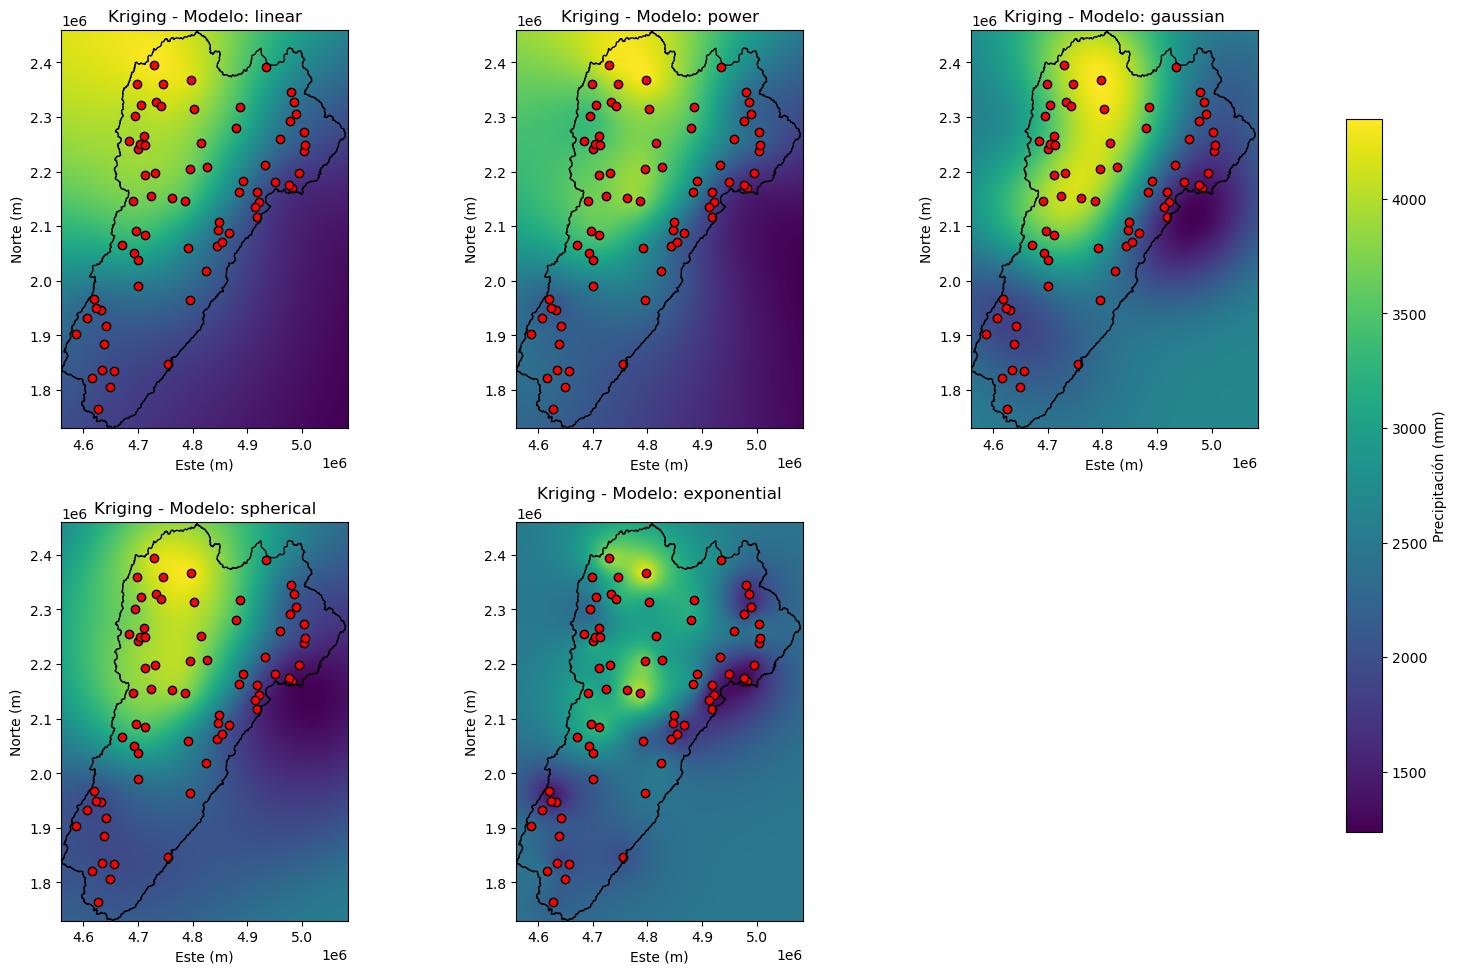

In [115]:

# === Cargar shapefile de zona de estudio y reproyectar a EPSG:9377 ===
ruta_shp = os.path.join("Zona_descargado", "ParteCuencaMagd.shp")
ZonaEstudio = gpd.read_file(ruta_shp).to_crs(epsg=9377)

# === Cargar puntos de lluvia y reproyectar a EPSG:9377 ===
ruta = os.path.join("Lluvia_total", "lluvia_temp_elevacion.gpkg")
gdf = gpd.read_file(ruta).to_crs(epsg=9377)

# === Extraer coordenadas en metros y valores ===
x_coords = gdf.geometry.x.values
y_coords = gdf.geometry.y.values
values = gdf["LluviaTotal_2022"].values

# === Verificar variabilidad de los datos ===
print(f"Min: {values.min()}, Max: {values.max()}, STD: {values.std()}")

# === Definir grilla (en metros) basada en los límites de la zona ===
resolucion = 5000  # resolución en metros
minx, miny, maxx, maxy = ZonaEstudio.total_bounds
gridx = np.arange(minx, maxx + resolucion, resolucion)
gridy = np.arange(miny, maxy + resolucion, resolucion)

# === Modelos de variograma a comparar ===
modelos = ['linear', 'power', 'gaussian', 'spherical', 'exponential']
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axs = axs.ravel()

for i, modelo in enumerate(modelos):
    try:
        OK = OrdinaryKriging(
            x_coords, y_coords, values,
            variogram_model=modelo,
            verbose=False,
            enable_plotting=False
        )
        z, ss = OK.execute('grid', gridx, gridy)

        # === Mostrar resultado ===
        im = axs[i].imshow(z, extent=(gridx.min(), gridx.max(), gridy.min(), gridy.max()),
                           origin='lower', cmap='viridis')

        # === Ajustar vista a la grilla interpolada ===
        axs[i].set_xlim(gridx.min(), gridx.max())
        axs[i].set_ylim(gridy.min(), gridy.max())

        # === Añadir puntos y contorno ===
        axs[i].scatter(x_coords, y_coords, c='red', edgecolors='k', label='Estaciones')
        ZonaEstudio.boundary.plot(ax=axs[i], color='black', linewidth=1)

        axs[i].set_title(f"Kriging - Modelo: {modelo}")
        axs[i].set_xlabel("Este (m)")
        axs[i].set_ylabel("Norte (m)")

    except Exception as e:
        axs[i].text(0.5, 0.5, f"Error: {e}", ha='center', va='center', transform=axs[i].transAxes)
        axs[i].set_title(f"Falló modelo: {modelo}")
        axs[i].axis('off')

# === Eliminar ejes vacíos si hay menos de 6 ===
if len(modelos) < len(axs):
    for j in range(len(modelos), len(axs)):
        fig.delaxes(axs[j])

# === Ajustes finales ===
plt.tight_layout()
plt.colorbar(im, ax=axs.tolist(), location='right', shrink=0.8, label="Precipitación (mm)")
plt.show()


=== Evaluación de modelos de variograma (LOOCV) ===
Modelo: linear → RMSE = 957.28, MAE = 759.88, Bias = 2.77
Modelo: power → RMSE = 878.91, MAE = 714.97, Bias = -4.53
Modelo: gaussian → RMSE = 915.65, MAE = 729.45, Bias = 16.71
Modelo: spherical → RMSE = 908.58, MAE = 730.70, Bias = 2.84
Modelo: exponential → RMSE = 834.86, MAE = 646.38, Bias = 24.87

✅ Mejor modelo: exponential con RMSE = 834.86


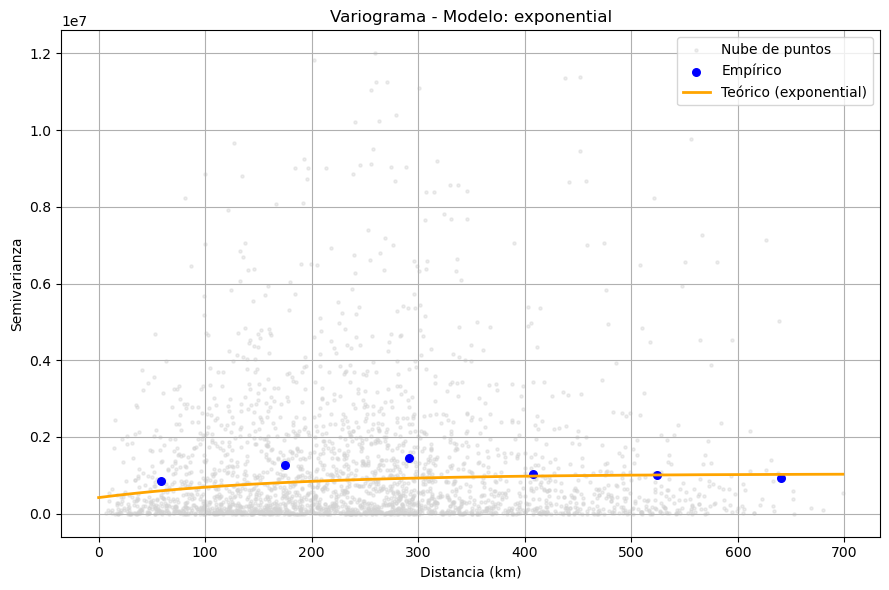

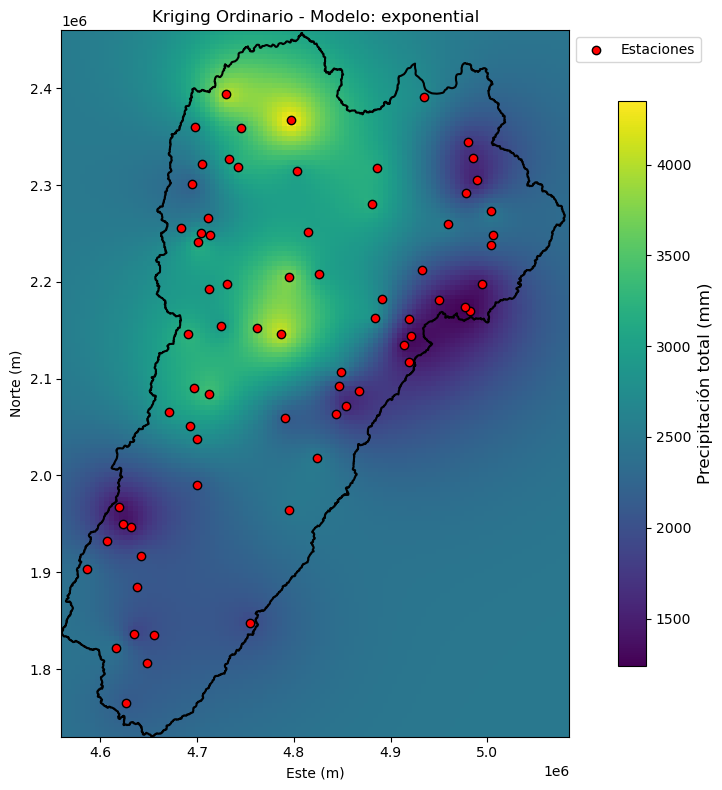


✅ Raster exportado correctamente a: Resultados\kriging_precipitacion_exponential.tif


In [144]:
# === Cargar shapefile y estaciones ===
ruta_shp = os.path.join("Zona_descargado", "ParteCuencaMagd.shp")
ruta_gpkg = os.path.join("Lluvia_total", "lluvia_temp_elevacion.gpkg")

ZonaEstudio = gpd.read_file(ruta_shp).to_crs(epsg=9377)
gdf = gpd.read_file(ruta_gpkg).to_crs(epsg=9377)

# === Extraer coordenadas y valores ===
x_coords = gdf.geometry.x.values
y_coords = gdf.geometry.y.values
values = gdf["LluviaTotal_2022"].values
coords = np.column_stack((x_coords, y_coords))

# === Modelos a evaluar con LOOCV ===
modelos = ['linear', 'power', 'gaussian', 'spherical', 'exponential']
rmse_dict = {}
mae_dict = {}
bias_dict = {}

print("=== Evaluación de modelos de variograma (LOOCV) ===")
for modelo in modelos:
    errores_cuad = []
    errores_abs = []
    sesgos = []
    for i in range(len(values)):
        x_train = np.delete(x_coords, i)
        y_train = np.delete(y_coords, i)
        v_train = np.delete(values, i)
        x_pred, y_pred = x_coords[i], y_coords[i]
        v_real = values[i]

        try:
            OK = OrdinaryKriging(x_train, y_train, v_train, variogram_model=modelo,
                                 verbose=False, enable_plotting=False)
            z, _ = OK.execute("points", [x_pred], [y_pred])
            error = v_real - z[0]
            errores_cuad.append(error**2)
            errores_abs.append(abs(error))
            sesgos.append(error)
        except Exception as e:
            print(f"Error con modelo {modelo} en punto {i}: {e}")
            errores_cuad.append(np.nan)
            errores_abs.append(np.nan)
            sesgos.append(np.nan)

    rmse = np.sqrt(np.nanmean(errores_cuad))
    mae = np.nanmean(errores_abs)
    bias = np.nanmean(sesgos)

    rmse_dict[modelo] = rmse
    mae_dict[modelo] = mae
    bias_dict[modelo] = bias

    print(f"Modelo: {modelo} → RMSE = {rmse:.2f}, MAE = {mae:.2f}, Bias = {bias:.2f}")

# === Seleccionar mejor modelo por RMSE ===
mejor_modelo = min(rmse_dict, key=rmse_dict.get)
print(f"\n✅ Mejor modelo: {mejor_modelo} con RMSE = {rmse_dict[mejor_modelo]:.2f}")

# === Ajustar Kriging con todo el conjunto y modelo óptimo ===
OK = OrdinaryKriging(x_coords, y_coords, values, variogram_model=mejor_modelo,
                     verbose=False, enable_plotting=False)

# === Calcular distancias y diferencias al cuadrado ===
dists = pdist(coords)
vals = pdist(values.reshape(-1, 1), metric='euclidean')**2
semivariances = vals / 2  # nube de puntos
bins = np.linspace(0, dists.max(), 7)  # se puede ajustar
bin_indices = np.digitize(dists, bins)
gamma_emp = [np.mean(semivariances[bin_indices == i]) for i in range(1, len(bins))]
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# === Extraer parámetros del modelo ===
sill, rang, nugget = OK.variogram_model_parameters
h_vals = np.linspace(0, dists.max(), 200)

# === FUNCIONES DE MODELO ===
def spherical(h, range_, sill, nugget):
    h = np.asarray(h)
    y = np.where(
        h <= range_,
        nugget + sill * (1.5 * h / range_ - 0.5 * (h / range_)**3),
        nugget + sill
    )
    return y

def exponential(h, range_, sill, nugget):
    return nugget + sill * (1 - np.exp(-h / range_))

def gaussian(h, range_, sill, nugget):
    return nugget + sill * (1 - np.exp(-(h / range_)**2))

def linear(h, range_, sill, nugget):
    return nugget + sill * (h / range_)

def power(h, range_, sill, nugget):
    return nugget + sill * ((h / range_) ** 0.5)

model_funcs = {
    "spherical": spherical,
    "exponential": exponential,
    "gaussian": gaussian,
    "linear": linear,
    "power": power
}

variograma_func = model_funcs[mejor_modelo]
gamma_teorico = variograma_func(h_vals, rang, sill, nugget)

# === GRAFICAR VARIOGRAMA COMPLETO ===
plt.figure(figsize=(9, 6))
plt.scatter(dists / 1000, semivariances, color='lightgray', s=5, alpha=0.4, label='Nube de puntos')
plt.scatter(bin_centers / 1000, gamma_emp, color='blue', s=30, label='Empírico')
plt.plot(h_vals / 1000, gamma_teorico, color='orange', linewidth=2, label=f'Teórico ({mejor_modelo})')
plt.title(f'Variograma - Modelo: {mejor_modelo}')
plt.xlabel('Distancia (km)')
plt.ylabel('Semivarianza')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Interpolación espacial ===
minx, miny, maxx, maxy = ZonaEstudio.total_bounds
resolucion = 5000
gridx = np.arange(minx, maxx + resolucion, resolucion)
gridy = np.arange(miny, maxy + resolucion, resolucion)
z, ss = OK.execute('grid', gridx, gridy)

# === Mapa de interpolación (valores reales) ===
plt.figure(figsize=(10, 8))
img = plt.imshow(z, extent=(gridx.min(), gridx.max(), gridy.min(), gridy.max()),
                 origin='lower', cmap='viridis', aspect='auto')
plt.xlim(gridx.min(), gridx.max())
plt.ylim(gridy.min(), gridy.max())
plt.scatter(x_coords, y_coords, c='red', edgecolors='k', label='Estaciones')
ZonaEstudio.boundary.plot(ax=plt.gca(), color='black', linewidth=1.5)
cbar = plt.colorbar(img, shrink=0.8)
cbar.set_label('Precipitación total (mm)', fontsize=12)
plt.title(f'Kriging Ordinario - Modelo: {mejor_modelo}')
plt.xlabel('Este (m)')
plt.ylabel('Norte (m)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


# === Definir resolución y transformada afín ===
res = resolucion  # ya definido antes
transform = from_origin(gridx.min(), gridy.max(), res, res)  # origen en esquina superior izquierda

# === Crear y guardar raster GeoTIFF ===
output_raster = os.path.join("Resultados", f"kriging_precipitacion_{mejor_modelo}.tif")
os.makedirs(os.path.dirname(output_raster), exist_ok=True)

with rasterio.open(
    output_raster,
    "w",
    driver="GTiff",
    height=z.shape[0],
    width=z.shape[1],
    count=1,
    dtype=z.dtype,
    crs="EPSG:9377",  # asegúrate que es el CRS correcto de trabajo
    transform=transform,
) as dst:
    dst.write(z, 1)

print(f"\n✅ Raster exportado correctamente a: {output_raster}")



El modelo de kriging ordinario con variograma esférico tiene un error promedio absoluto (MAE) de 646.4 mm de precipitación, lo que indica que las predicciones difieren en promedio por ese valor respecto a los datos observados.
Además, el bias positivo de 24.87 mm indica que el modelo tiende a sobreestimar.
Se analizó también incluyendo estaciiones cercanas, pero ubicadas fuera de la cuenca y el ajuste al variograma se ve muy efectada. El MAE llega a tomar valores amyores al 1200 y el bias mayores a 100

✅ Convex Hull exportado correctamente a: ConvexHull\convex_hull.shp


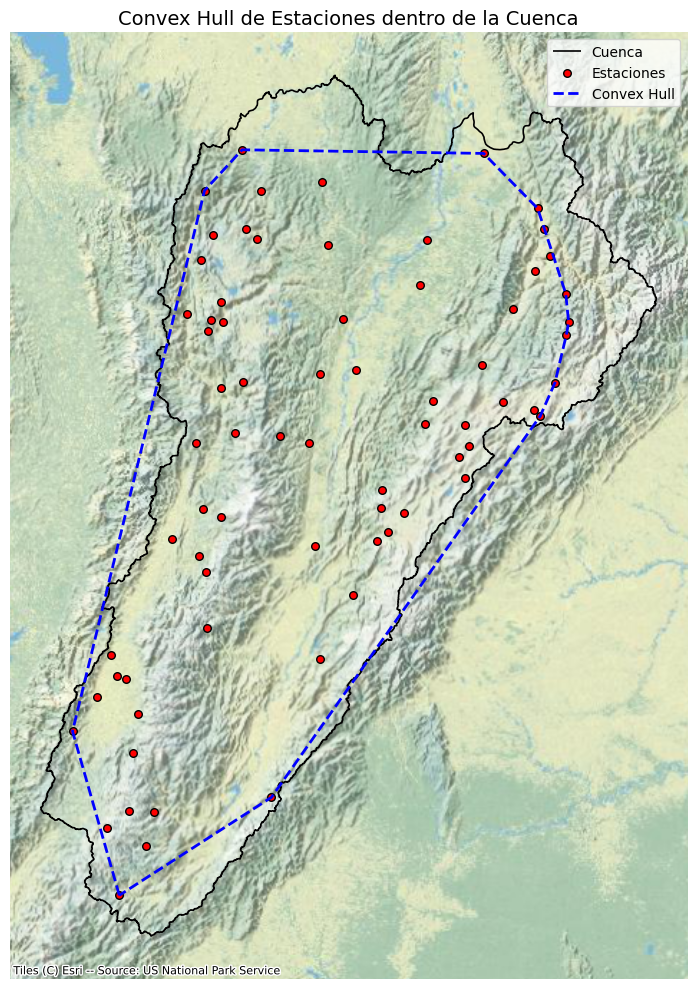

In [145]:

# === RUTAS ===
ruta_cuenca = os.path.join("Zona_descargado", "ParteCuencaMagd.shp")
ruta_gpkg = os.path.join("Lluvia_total", "lluvia_temp_elevacion.gpkg")
ruta_salida = os.path.join("ConvexHull", "convex_hull.shp")
os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)

# === CARGAR DATOS ===
cuenca = gpd.read_file(ruta_cuenca).to_crs(epsg=9377)
gdf = gpd.read_file(ruta_gpkg).to_crs(epsg=9377)

# === ESTACIONES DENTRO DE LA CUENCA ===
union_cuenca = cuenca.unary_union
estaciones_dentro = gdf[gdf.geometry.within(union_cuenca)]

# === CALCULAR CONVEX HULL CLÁSICO (de puntos dentro de cuenca) ===
if estaciones_dentro.empty:
    raise ValueError("❌ No hay estaciones dentro de la cuenca.")

multipoint = MultiPoint(estaciones_dentro.geometry.tolist())
convex_hull_geom = multipoint.convex_hull

# === EXPORTAR SHAPEFILE ===
gdf_hull = gpd.GeoDataFrame(geometry=[convex_hull_geom], crs=9377)
gdf_hull.to_file(ruta_salida)
print(f"✅ Convex Hull exportado correctamente a: {ruta_salida}")

# === GRAFICAR ===
fig, ax = plt.subplots(figsize=(10, 10))
cuenca.boundary.plot(ax=ax, color='black', linewidth=1.2, label="Cuenca")
estaciones_dentro.plot(ax=ax, color='red', markersize=30, edgecolor='k', label="Estaciones")
gdf_hull.boundary.plot(ax=ax, color='blue', linewidth=2, linestyle='--', label="Convex Hull")

# === Basemap ===
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldPhysical, crs=9377)

# === Detalles ===
ax.set_title("Convex Hull de Estaciones dentro de la Cuenca", fontsize=14)
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()



#### Krigging universal

##### Se asiganan los valores de la prercipitación satelital

In [146]:


# === RUTA DEL ARCHIVO .tif ===
ruta_raster = os.path.join("PrecipitacionImerg", "precip_2022_total.tif")  # <--- CAMBIA ESTO

# === CARGAR TU GeoDataFrame DE ESTACIONES ===
ruta = os.path.join("Lluvia_total", "lluvia_temp_elevacion.gpkg")
gdf = gpd.read_file(ruta)

# === EXTRAER VALORES DEL RASTER A CADA PUNTO ===
with rasterio.open(ruta_raster) as src:
    # Reproyectar puntos al CRS del raster
    gdf = gdf.to_crs(src.crs)
    
    # Inicializar lista para valores extraídos
    valores_extraidos = []

    for geom in gdf.geometry:
        coords = [(geom.x, geom.y)]
        for val in src.sample(coords):
            valores_extraidos.append(val[0])

# === AÑADIR LA COLUMNA AL GDF ===
gdf["Precipitacion_Satelital"] = valores_extraidos

# === GUARDAR EL NUEVO GPKG (opcional) ===
salida = os.path.join("Lluvia_total", "lluvia_temp_elevacion_con_sat.gpkg")
gdf.to_file(salida, driver="GPKG")

print("✓ Columna 'Precipitacion_Satelital' añadida con éxito.")
print("✓ Guardado en:", salida)


✓ Columna 'Precipitacion_Satelital' añadida con éxito.
✓ Guardado en: Lluvia_total\lluvia_temp_elevacion_con_sat.gpkg


###### ejecucion de kriging universal

###### Regresion de tendencia

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     50.64
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.92e-14
Time:                        02:13:26   Log-Likelihood:                -572.88
No. Observations:                  72   AIC:                             1152.
Df Residuals:                      69   BIC:                             1159.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        713.9854    375.156      1.903      0.0

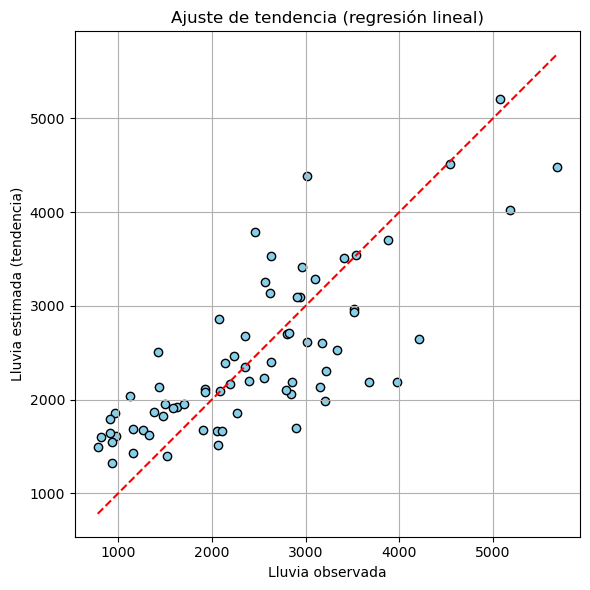

In [147]:


# === 1. Cargar datos y reproyectar ===
ruta = os.path.join("Lluvia_total", "lluvia_temp_elevacion_con_sat.gpkg")
gdf = gpd.read_file(ruta).to_crs(epsg=9377)  # CRS de trabajo

# === 2. Extraer variables relevantes ===
Z = gdf["LluviaTotal_2022"].values  # Variable dependiente (precipitación total)
elev = gdf["Elevacion"].values      # Covariable 1: elevación
sat = gdf["Precipitacion_Satelital"].values  # Covariable 2: precipitación satelital
coords = np.array([(geom.x, geom.y) for geom in gdf.geometry])  # Coordenadas

# === 3. Filtrar valores válidos (sin NaN ni inf) === se eliminan las estaciones que tienen datos nan
mascara_validos = np.isfinite(Z) & np.isfinite(elev) & np.isfinite(sat)
Z = Z[mascara_validos]
elev = elev[mascara_validos]
sat = sat[mascara_validos]
coords = coords[mascara_validos]

# === 4. Ajustar modelo de regresión múltiple ===
X = np.column_stack((elev, sat))   # Matriz de diseño: elevación y precipitación satelital
X_sm = sm.add_constant(X)          # Se añade el intercepto
modelo = sm.OLS(Z, X_sm).fit()     # Ajuste del modelo lineal

# === 5. Mostrar resumen estadístico ===
print(modelo.summary())

# === 6. Asociar nombres a los coeficientes ===
nombres = ["Intercepto", "Elevación", "Precipitación satelital"]
for nombre, coef in zip(nombres, modelo.params):
    print(f"{nombre:<25}: {coef:.4f}")

# === 7. Calcular tendencia y residuos ===
Z_trend = modelo.predict(X_sm)  # Estimación de la tendencia (componente determinista)
residuals = Z - Z_trend         # Residuos (componente estocástico)

# === 8. Visualizar ajuste observado vs estimado ===
plt.figure(figsize=(6, 6))
plt.scatter(Z, Z_trend, edgecolor='k', c='skyblue')
plt.plot([Z.min(), Z.max()], [Z.min(), Z.max()], 'r--')
plt.xlabel("Lluvia observada")
plt.ylabel("Lluvia estimada (tendencia)")
plt.title("Ajuste de tendencia (regresión lineal)")
plt.grid(True)
plt.tight_layout()
plt.show()



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     102.7
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.28e-15
Time:                        02:13:27   Log-Likelihood:                -572.89
No. Observations:                  72   AIC:                             1150.
Df Residuals:                      70   BIC:                             1154.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        680.6392    192.322      3.539      0.0

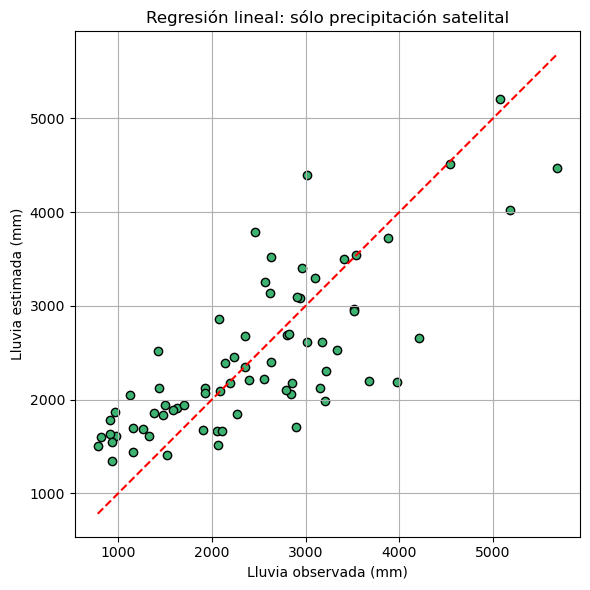

In [148]:

# === Cargar y reproyectar ===
ruta = os.path.join("Lluvia_total", "lluvia_temp_elevacion_con_sat.gpkg")
gdf = gpd.read_file(ruta).to_crs(epsg=9377)

# === Filtrar outliers en LluviaTotal_2022 (más de 3σ) ===
lluvia = gdf["LluviaTotal_2022"]
media = lluvia.mean()
std = lluvia.std()
gdf = gdf[(lluvia >= media - 3*std) & (lluvia <= media + 3*std)].copy()

# === Variables ===
Z = gdf["LluviaTotal_2022"].values
sat = gdf["Precipitacion_Satelital"].values
coords = np.array([(geom.x, geom.y) for geom in gdf.geometry])

# === Ajustar regresión con SOLO precipitación satelital ===
X = sat.reshape(-1, 1)           # variable explicativa
X_sm = sm.add_constant(X)        # agrega intercepto
modelo = sm.OLS(Z, X_sm).fit()   # ajuste OLS

# === Mostrar resumen estadístico ===
print(modelo.summary())  # p-valores, R², coeficientes, etc.

# === Asociar coeficientes con nombre ===
print(f"{'Intercepto':<25}: {modelo.params[0]:.4f}")
print(f"{'Precipitación satelital':<25}: {modelo.params[1]:.4f}")

# === Calcular residuos ===
Z_trend = modelo.predict(X_sm)
residuals = Z - Z_trend

# === Graficar Observado vs Estimado ===
plt.figure(figsize=(6, 6))
plt.scatter(Z, Z_trend, edgecolor='k', c='mediumseagreen')
plt.plot([Z.min(), Z.max()], [Z.min(), Z.max()], 'r--')
plt.xlabel("Lluvia observada (mm)")
plt.ylabel("Lluvia estimada (mm)")
plt.title("Regresión lineal: sólo precipitación satelital")
plt.grid(True)
plt.tight_layout()
plt.show()


In [149]:
#### variación espacial de los residuos?

In [150]:


# === 1. Cargar estaciones con residuos ===
ruta_gpkg = os.path.join("Lluvia_total", "lluvia_temp_elevacion_con_sat.gpkg")
gdf = gpd.read_file(ruta_gpkg).to_crs(epsg=9377)

# === 2. Calcular residuos de la regresión lineal ===
Z = gdf["LluviaTotal_2022"].values
sat = gdf["Precipitacion_Satelital"].values
X = sm.add_constant(sat)
modelo = sm.OLS(Z, X).fit()
residuos = Z - modelo.predict(X)
gdf["residuos"] = residuos

# === 3. Construir matriz de pesos por distancia (hasta 50 km, ajustable) ===
coords = np.array([(geom.x, geom.y) for geom in gdf.geometry])
w = DistanceBand(coords, threshold=50000, binary=True, silence_warnings=True)

# === 4. Calcular índice de Moran ===
moran = Moran(residuos, w)

# === 5. Imprimir resultados ===
print("=== Índice de Moran para los residuos ===")
print(f"I de Moran : {moran.I:.4f}")
print(f"p-valor    : {moran.p_sim:.4f}")
print(f"z-score    : {moran.z_sim:.2f}")

# === 6. Interpretación rápida ===
if moran.p_sim < 0.05:
    print("Hay evidencia de autocorrelación espacial significativa en los residuos para distancias de 50 km. (long de área: 730 km)")
else:
    print("⚠️ No se detecta autocorrelación espacial significativa.")


=== Índice de Moran para los residuos ===
I de Moran : 0.2972
p-valor    : 0.0040
z-score    : 3.03
Hay evidencia de autocorrelación espacial significativa en los residuos para distancias de 50 km. (long de área: 730 km)


In [151]:
##### Definicion de variograma para los residuos

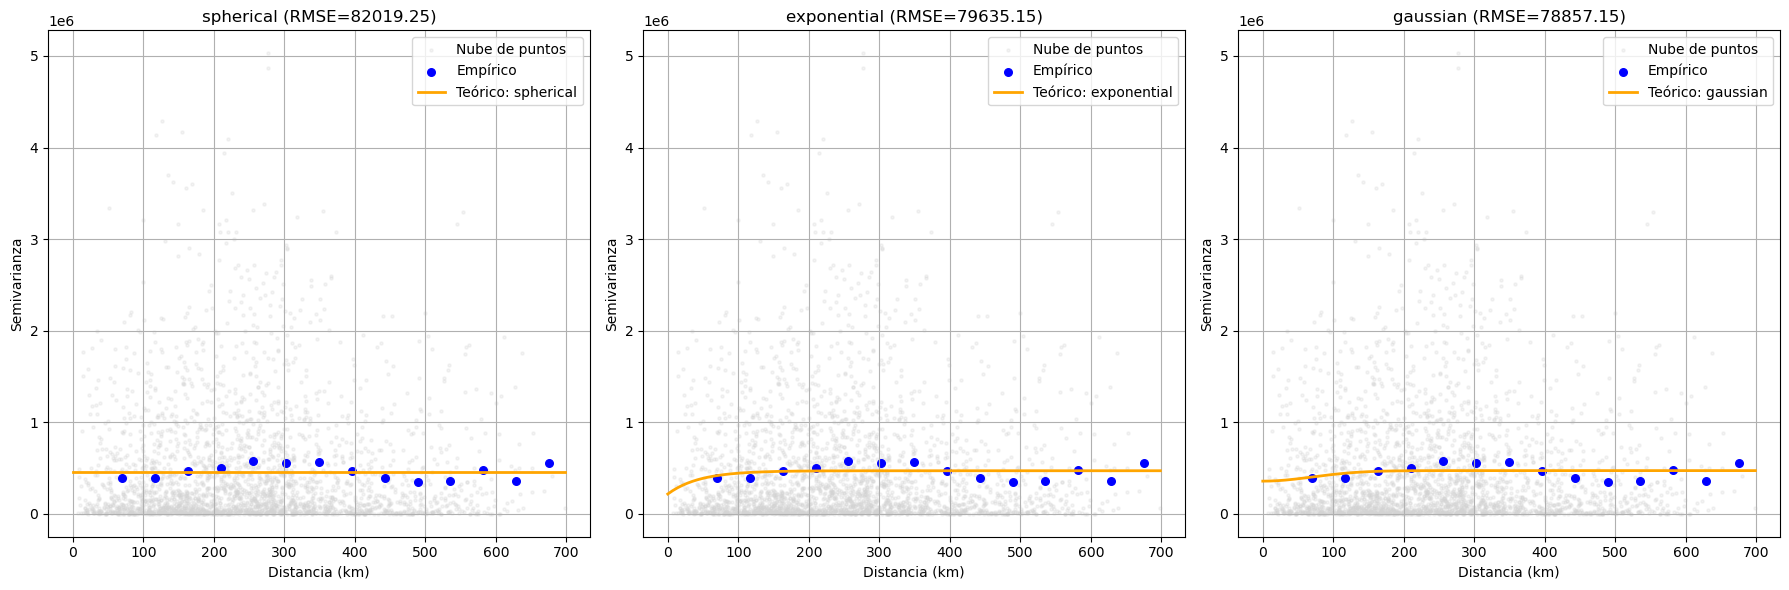


✅ Mejor modelo de variograma (residuos): gaussian (RMSE = 78857.15)


In [152]:

# === Calcular distancias y diferencias ===
dist_matrix = squareform(pdist(coords))
diff_matrix = squareform(pdist(residuals[:, None]))**2
distances = dist_matrix[np.triu_indices(len(coords), k=1)]
diffs_squared = diff_matrix[np.triu_indices(len(coords), k=1)]

# === Evaluar modelos ===
modelos_validos = ['spherical', 'exponential', 'gaussian']
rmse_dict = {}

fig, axs = plt.subplots(1, len(modelos_validos), figsize=(18, 6))
axs = axs.ravel()

for i, modelo in enumerate(modelos_validos):
    try:
        V = Variogram(
            coordinates=coords,
            values=residuals,
            model=modelo,
            n_lags=15,
            normalize=False,
            use_nugget=True,
            fit_method='trf',
            fit_kwargs={"max_nfev": 5000}
        )

        # Obtener centros y semivarianza empírica
        bin_edges = V.bins
        centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
        gamma_empirico = V.experimental

        # Asegurar longitudes consistentes
        valid_bins = min(len(centers), len(gamma_empirico))
        centers = centers[:valid_bins]
        gamma_empirico = gamma_empirico[:valid_bins]

        # Evaluar modelo teórico
        gamma_teorico = V.fitted_model(centers)

        # Calcular RMSE
        rmse = np.sqrt(mean_squared_error(gamma_empirico, gamma_teorico))
        rmse_dict[modelo] = rmse

        # Graficar
        ax = axs[i]
        ax.scatter(distances / 1000, 0.5 * diffs_squared, color='lightgray', alpha=0.25, s=5, label='Nube de puntos')
        ax.scatter(centers / 1000, gamma_empirico, color='blue', label='Empírico', s=30)
        h_vals = np.linspace(0, bin_edges[-1], 200)
        ax.plot(h_vals / 1000, V.fitted_model(h_vals), color='orange', linewidth=2, label=f'Teórico: {modelo}')
        ax.set_title(f"{modelo} (RMSE={rmse:.2f})")
        ax.set_xlabel("Distancia (km)")
        ax.set_ylabel("Semivarianza")
        ax.grid(True)
        ax.legend()

    except Exception as e:
        print(f"❌ Error en modelo {modelo}: {e}")

plt.tight_layout()
plt.show()

# === Elegir mejor modelo ===
if rmse_dict:
    mejor_modelo = min(rmse_dict, key=rmse_dict.get)
    print(f"\n✅ Mejor modelo de variograma (residuos): {mejor_modelo} (RMSE = {rmse_dict[mejor_modelo]:.2f})")
else:
    raise ValueError("⚠️ No se pudo ajustar ningún modelo de variograma.")



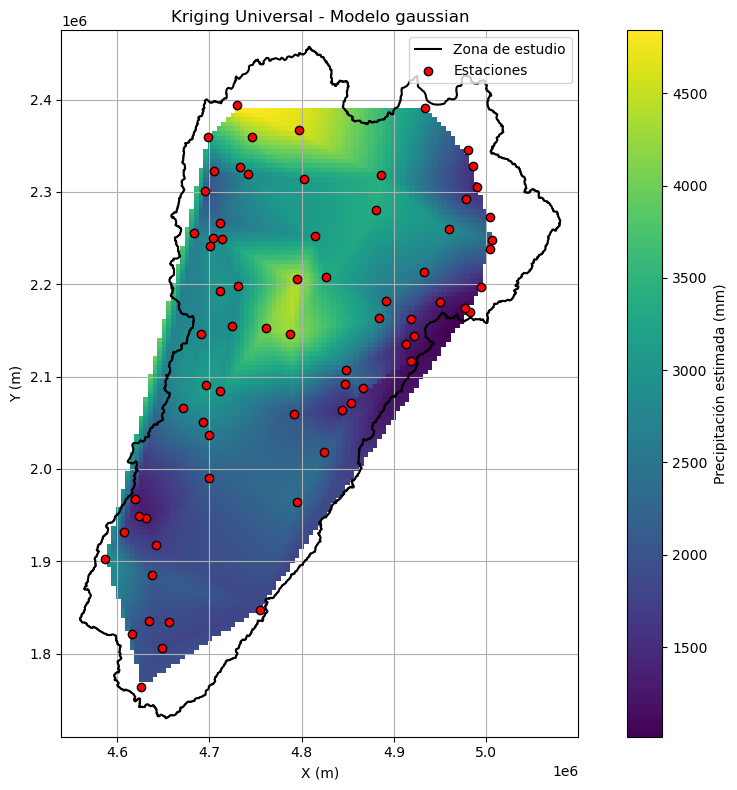

In [153]:


# === RUTAS ===
ruta_puntos = os.path.join("Lluvia_total", "lluvia_temp_elevacion_con_sat.gpkg")
ruta_zona = os.path.join("Zona_descargado", "ParteCuencaMagd.shp")

# === CARGA Y PROYECCIÓN ===
gdf = gpd.read_file(ruta_puntos).to_crs(epsg=9377)
zona = gpd.read_file(ruta_zona).to_crs(epsg=9377)

# === VARIABLES ===
coords = np.array([(geom.x, geom.y) for geom in gdf.geometry])
Z = gdf["LluviaTotal_2022"].values
sat = gdf["Precipitacion_Satelital"].values

# === AJUSTAR TENDENCIA CON REGRESIÓN ===
X = sm.add_constant(sat.reshape(-1, 1))
modelo = sm.OLS(Z, X).fit()
Z_trend = modelo.predict(X)
residuals = Z - Z_trend

# === DEFINIR GRILLA EXTENDIDA ===
minx, miny, maxx, maxy = zona.total_bounds
buffer = 20000  # 20 km adicionales
resolucion = 5000  # en metros
gridx = np.arange(minx - buffer, maxx + buffer, resolucion)
gridy = np.arange(miny - buffer, maxy + buffer, resolucion)
grid_xx, grid_yy = np.meshgrid(gridx, gridy)
puntos_grilla = np.column_stack((grid_xx.ravel(), grid_yy.ravel()))

# === KRIGING DE RESIDUALES ===
OK = OrdinaryKriging(
    coords[:, 0],
    coords[:, 1],
    residuals,
    variogram_model='gaussian',
    verbose=False,
    enable_plotting=False
)
z_residuals, _ = OK.execute("grid", gridx, gridy)

# === INTERPOLAR SATELITAL A LA GRILLA ===
sat_interp = griddata(coords, sat, puntos_grilla, method='linear')
sat_grid = sat_interp.reshape(grid_yy.shape)

# === EVALUAR TENDENCIA EN LA GRILLA ===
intercepto = modelo.params[0]
coef_sat = modelo.params[1]
Z_trend_grid = intercepto + coef_sat * sat_grid

# === KRIGING UNIVERSAL FINAL ===
Z_universal = Z_trend_grid + z_residuals

# === GRAFICAR RESULTADO ===
plt.figure(figsize=(10, 8))
img = plt.imshow(
    Z_universal,
    extent=(gridx.min(), gridx.max(), gridy.min(), gridy.max()),
    origin='lower',
    cmap='viridis'
)
zona.boundary.plot(ax=plt.gca(), edgecolor='black', linewidth=1.5, label='Zona de estudio')
plt.scatter(coords[:, 0], coords[:, 1], c='red', edgecolors='k', label='Estaciones', zorder=10)
plt.colorbar(img, label='Precipitación estimada (mm)')
plt.title("Kriging Universal - Modelo gaussian")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


R² (LOOCV): 0.635

 Evaluación Kriging Universal (LOOCV)
RMSE  : 655.91
MAE   : 517.24
Sesgo : 0.05


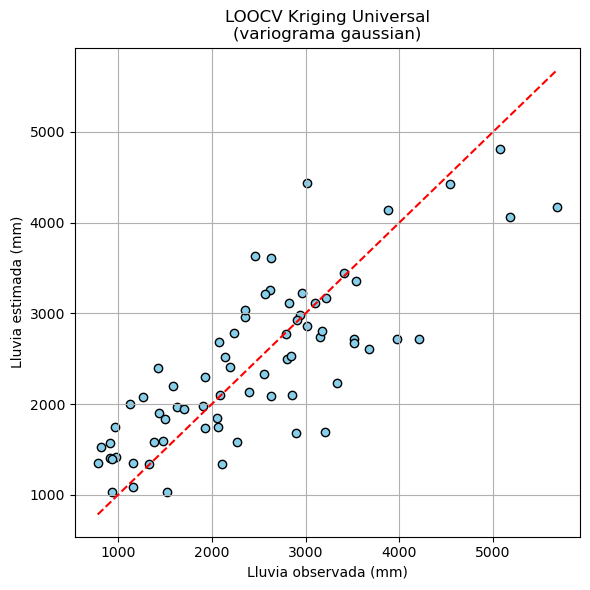

In [157]:

# === Coordenadas y variables ===
Z = gdf["LluviaTotal_2022"].values
sat = gdf["Precipitacion_Satelital"].values
coords = np.array([(geom.x, geom.y) for geom in gdf.geometry])

# === Ajuste tendencia global con precipitación satelital ===
X = sm.add_constant(sat.reshape(-1, 1))
modelo = sm.OLS(Z, X).fit()
Z_trend = modelo.predict(X)
residuals = Z - Z_trend

# === Validación cruzada Leave-One-Out ===
observados = []
estimados = []

for i in range(len(Z)):
    coords_train = np.delete(coords, i, axis=0)
    residuals_train = np.delete(residuals, i)
    x_i, y_i = coords[i]

    try:
        OK = OrdinaryKriging(
            coords_train[:, 0], coords_train[:, 1], residuals_train,
            variogram_model='gaussian',
            verbose=False,
            enable_plotting=False
        )
        z_res, _ = OK.execute("points", [x_i], [y_i])
        
        # Estimar tendencia para ese punto
        tendencia = modelo.params[0] + modelo.params[1] * sat[i]
        z_est = z_res[0] + tendencia

        observados.append(Z[i])
        estimados.append(z_est)

    except Exception as e:
        print(f"⚠️ Error en punto {i}: {e}")

# === Métricas ===
observados = np.array(observados)
estimados = np.array(estimados)
rmse = np.sqrt(mean_squared_error(observados, estimados))
mae = mean_absolute_error(observados, estimados)
sesgo = np.mean(estimados - observados)
# === Valores observados y estimados del LOOCV
observados = np.array(observados)
estimados = np.array(estimados)

# === Cálculo de R²
from sklearn.metrics import r2_score
r2 = r2_score(observados, estimados)

print(f"R² (LOOCV): {r2:.3f}")

print("\n Evaluación Kriging Universal (LOOCV)")
print(f"RMSE  : {rmse:.2f}")
print(f"MAE   : {mae:.2f}")
print(f"Sesgo : {sesgo:.2f}")

# === Gráfica Observado vs Estimado ===
plt.figure(figsize=(6, 6))
plt.scatter(observados, estimados, edgecolors='k', c='skyblue')
plt.plot([observados.min(), observados.max()], [observados.min(), observados.max()], 'r--')
plt.xlabel("Lluvia observada (mm)")
plt.ylabel("Lluvia estimada (mm)")
plt.title("LOOCV Kriging Universal\n(variograma gaussian)")
plt.grid(True)
plt.tight_layout()
plt.show()


| **Métrica**                           | **¿Qué mide?**                                        | **Valor**     | **Interpretación**                                                   |
| ------------------------------------- | ----------------------------------------------------- | ------------- | -------------------------------------------------------------------- |
| **RMSE**<br>(Root Mean Squared Error) | Magnitud promedio del error cuadrático                | **655.91 mm** | Error promedio elevado; penaliza más los errores grandes             |
| **MAE**<br>(Mean Absolute Error)      | Promedio de errores absolutos (sin importar el signo) | **517.24 mm** | En promedio, el modelo se equivoca por \~517 mm                      |
| **Sesgo (Bias)**                      | Promedio de (estimado - observado)                    | **0.05 mm**   | Modelo **ligeramente subestimador**, pero el sesgo neto es casi nulo |
🔎 Conclusión: Aunque el sesgo es bajo, los errores individuales son muy altos (RMSE y MAE elevados), lo que sugiere que el modelo no representa bien la variabilidad local de la lluvia. El bajo sesgo se debe a que se compensan errores positivos y negativos.

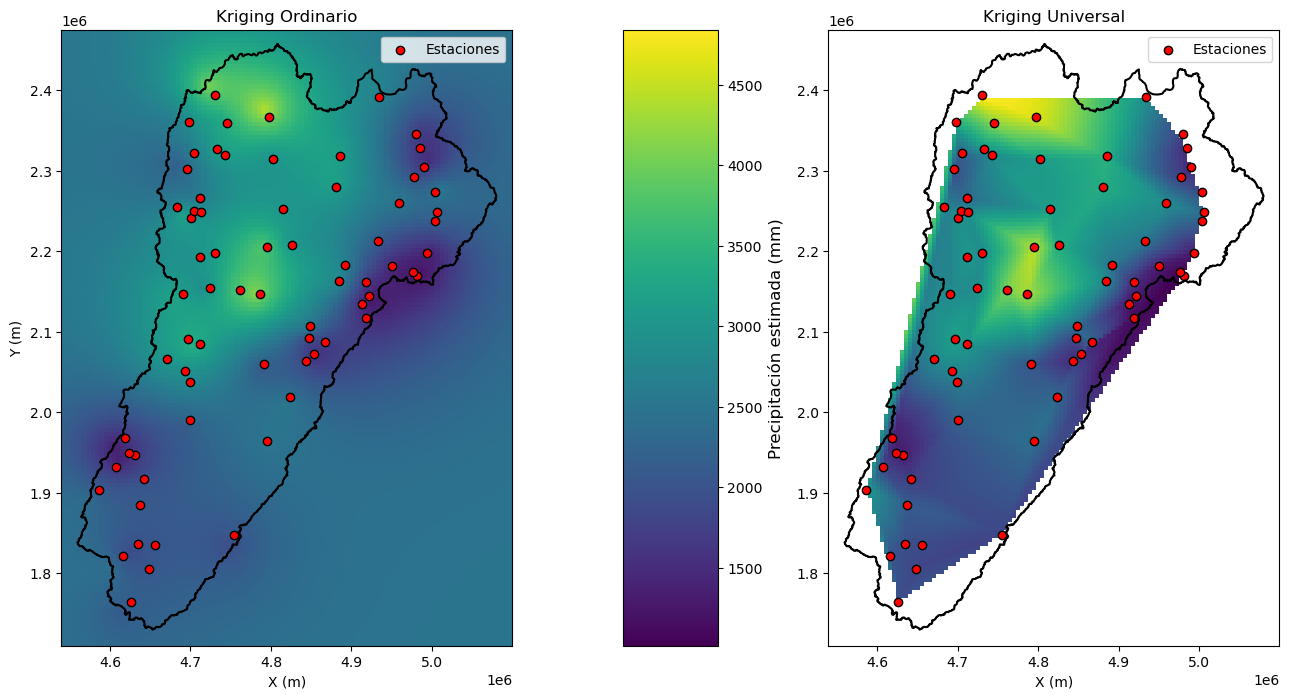

In [155]:


# === Calcular límites comunes para la escala de color ===
vmin = min(np.nanmin(z), np.nanmin(Z_universal))
vmax = max(np.nanmax(z), np.nanmax(Z_universal))

# === Crear figura con gridspec para controlar la ubicación del colorbar ===
fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 0.15, 1], wspace=0.05)

# === Kriging Ordinario ===
ax0 = plt.subplot(gs[0])
img0 = ax0.imshow(z, extent=(gridx.min(), gridx.max(), gridy.min(), gridy.max()),
                  origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
zona.boundary.plot(ax=ax0, edgecolor='black', linewidth=1.5)
ax0.scatter(x_coords, y_coords, c='red', edgecolors='k', label='Estaciones')
ax0.set_title("Kriging Ordinario")
ax0.set_xlabel("X (m)")
ax0.set_ylabel("Y (m)")
ax0.legend()

# === Kriging Universal ===
ax2 = plt.subplot(gs[2])
img2 = ax2.imshow(Z_universal, extent=(gridx.min(), gridx.max(), gridy.min(), gridy.max()),
                  origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
zona.boundary.plot(ax=ax2, edgecolor='black', linewidth=1.5)
ax2.scatter(coords[:, 0], coords[:, 1], c='red', edgecolors='k', label='Estaciones')
ax2.set_title("Kriging Universal")
ax2.set_xlabel("X (m)")
ax2.legend()

# === Barra de color al centro ===
cax = plt.subplot(gs[1])
cbar = plt.colorbar(img2, cax=cax)
cbar.set_label("Precipitación estimada (mm)", fontsize=12)

plt.tight_layout()
plt.show()
